In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('Customer-Churn-Records.csv')


In [3]:
%matplotlib inline

In [4]:
print(df.head())
print(df.info())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  Complain  Satisfaction Score Card Type  \
0        101348.88       1         1                   2   DIAMOND   
1        112542.58

In [5]:
df=df.drop(['RowNumber','Surname','CustomerId','Complain'],axis=1)
print(df.head())

   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  Satisfaction Score  \
0          1               1        101348.88       1                   2   
1          0               1        112542.58       0                   3   
2          1               0        113931.57       1                   3   
3          0               0         93826.63       0                   5   
4          1               1         79084.10       0                   5   

  Card Type  Point Earned  
0   DIAMOND           464  
1   DIAMOND           456  
2 

In [6]:
df['Gender']=df['Gender'].map({'Male':1,'Female':0})
df=pd.get_dummies(df,columns=['Geography','Card Type'],drop_first=True)


In [7]:
print(df.head())

   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Satisfaction Score  Point Earned  \
0               1        101348.88       1                   2           464   
1               1        112542.58       0                   3           456   
2               0        113931.57       1                   3           377   
3               0         93826.63       0                   5           350   
4               1         79084.10       0                   5           425   

   Geography_Germany  Geography_Spain  Card Type_GOLD  Card Ty

In [8]:
# 数据切分
from sklearn.model_selection import train_test_split
X=df.drop('Exited',axis=1)
y=df['Exited']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
X_pseudo_train,X_pseudo_test,y_pseudo_train,y_pseudo_test=train_test_split(X_train,y_train,test_size=0.25,random_state=42,stratify=y_train)
print(f"X训练集的大小是{X_train.shape[0]}")
print(f"X的pseudo训练集的大小是{X_pseudo_train.shape[0]}")

X训练集的大小是8000
X的pseudo训练集的大小是6000


In [9]:
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=42)
X_pseudo_train_resampled,y_pseudo_train_resampled=sm.fit_resample(X_pseudo_train,y_pseudo_train)
print(f"平衡前流失/未流失的比例为:{y_pseudo_train.value_counts(normalize=True)}")
print(f"平衡后流失/未流失的比例为:{y_pseudo_train_resampled.value_counts(normalize=True)}")

平衡前流失/未流失的比例为:Exited
0    0.796167
1    0.203833
Name: proportion, dtype: float64
平衡后流失/未流失的比例为:Exited
0    0.5
1    0.5
Name: proportion, dtype: float64


准确率是:0.5190
分类报告如下所示:
              precision    recall  f1-score   support

           0       0.49      0.84      0.62       915
           1       0.65      0.24      0.36      1085

    accuracy                           0.52      2000
   macro avg       0.57      0.54      0.49      2000
weighted avg       0.58      0.52      0.47      2000



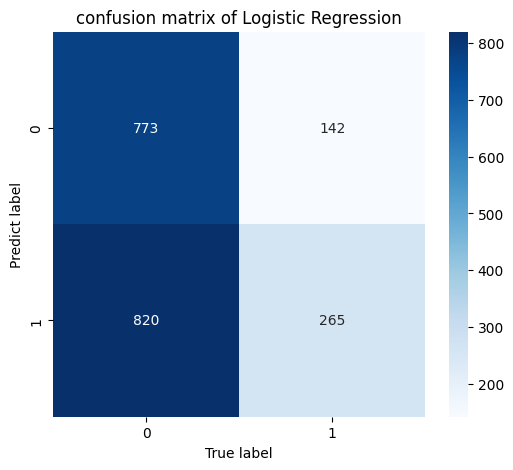

In [10]:
# 逻辑回归
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
model_LR=LogisticRegression(random_state=42,max_iter=1000,solver='saga')
model_LR.fit(X_pseudo_train_resampled,y_pseudo_train_resampled)
y_pred=model_LR.predict(X_pseudo_test)
accuracy=accuracy_score(y_pred,y_pseudo_test)
print(f"准确率是:{accuracy:.4f}")
print(f"分类报告如下所示:\n{classification_report(y_pred,y_pseudo_test)}")

cm=confusion_matrix(y_pred,y_pseudo_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('confusion matrix of Logistic Regression')
plt.xlabel('True label')
plt.ylabel('Predict label')
plt.show()

In [11]:
# 交叉检验
from sklearn.model_selection import cross_val_score
LR_CV=LogisticRegression(random_state=42,max_iter=1000,solver='saga')
Accuracy_score=cross_val_score(LR_CV,X_pseudo_train_resampled,y_pseudo_train_resampled,cv=5,scoring='accuracy')
print(f"F-fold得到的准确率是:\n{Accuracy_score}")
print(f"F-fold得到的准确率平均值是:\n{Accuracy_score.mean():.4f}")

Recall_score=cross_val_score(LR_CV,X_pseudo_train_resampled,y_pseudo_train_resampled,cv=5,scoring='recall')
print(f"F-fold得到的Recall结果是:\n{Recall_score}")
print(f"F-fold得到的Recall平均值是:\n{Recall_score.mean():.4f}")


F-fold得到的准确率是:
[0.56200942 0.58817373 0.57980115 0.57718472 0.58534031]
F-fold得到的准确率平均值是:
0.5785
F-fold得到的Recall结果是:
[0.65445026 0.70575916 0.66004184 0.67782427 0.66596859]
F-fold得到的Recall平均值是:
0.6728
